In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns
import sys

In [2]:
df = pd.read_csv("data/ACMETelephoneABT.csv")
y_label = 'churn'
df

,customer,age,occupation,regionType,marriageStatus,children,income,numHandsets,handsetAge,smartPhone,...,avgInCalls,peakOffPeakRatio,peakOffPeakRatioChangePct,avgDroppedCalls,lifeTime,lastMonthCustomerCareCalls,numRetentionCalls,numRetentionOffersAccepted,newFrequentNumbers,churn
0,1000004,26,crafts,town,yes,True,6,1,1812,False,...,0.00,0.362398,-6.330770,0.00,60,0.00,0,0,0,False
1,1000012,36,NaN,NaN,yes,True,9,4,544,True,...,1.67,5.586826,7.499560,0.00,53,0.00,0,0,0,False
2,1000034,74,professional,town,yes,False,7,2,138,True,...,0.33,0.500000,-5.940493,4.33,58,0.00,0,0,3,False
3,1000063,30,NaN,suburban,no,False,6,3,122,True,...,4.67,8.629661,-0.066485,5.33,50,0.33,0,0,0,False
4,1000085,32,NaN,town,yes,False,7,8,10,True,...,23.00,14.042685,-7.208502,14.67,56,0.00,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1099911,52,clerical,unknown,yes,False,4,1,892,True,...,1.00,0.635184,-4.321789,1.33,30,0.00,0,0,0,True
9996,1099923,36,NaN,NaN,yes,False,4,8,337,True,...,1.67,0.794198,0.518042,11.33,33,0.00,0,0,2,True
9997,1099939,28,professional,NaN,no,False,2,4,127,True,...,1.00,0.905522,-1.874074,7.67,33,1.00,0,0,0,True
9998,1099965,0,NaN,NaN,unknown,False,7,5,53,True,...,6.33,1.058214,-18.707600,16.00,31,7.33,0,0,0,True


In [53]:
df.isna().sum()

customer                         0
age                              0
occupation                    7400
regionType                    4776
marriageStatus                   0
children                         0
income                           0
numHandsets                      0
handsetAge                       0
smartPhone                       0
currentHandsetPrice              0
creditRating                     0
homeOwner                        0
creditCard                       0
avgBill                          0
avgMins                          0
avgrecurringCharge               0
avgOverBundleMins                0
avgRoamCalls                     0
callMinutesChangePct             0
billAmountChangePct              0
avgReceivedMins                  0
avgOutCalls                      0
avgInCalls                       0
peakOffPeakRatio                 0
peakOffPeakRatioChangePct        0
avgDroppedCalls                  0
lifeTime                         0
lastMonthCustomerCar

In [3]:
df['age'] = df['age'].replace(0, np.nan)
age_imputer = KNNImputer(n_neighbors=2)
df['age'] = age_imputer.fit_transform(df['age'].values.reshape(-1, 1)).reshape(1, -1)[0]
df['occupation'].fillna('missing', inplace=True)
df['regionType'].fillna('missing', inplace=True)
df['regionType'] = df['regionType'].replace({'unknown': 'missing', 'r': 'rural', 's': 'suburban', 't': 'town'})

df['children'] = df['children'].map({True: 1, False: 0})
df['smartPhone'] = df['smartPhone'].map({True: 1, False: 0})
df['homeOwner'] = df['homeOwner'].map({True: 1, False: 0})
df['creditCard'] = df['creditCard'].map({'TRUE': 1, 'FALSE': 0, 'no': 0, 't': 1, 'f': 0, 'yes': 1})
df['creditRating'] = df['creditRating'].map({'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1})
df['churn'] = df['churn'].map({True: 1, False: 0})

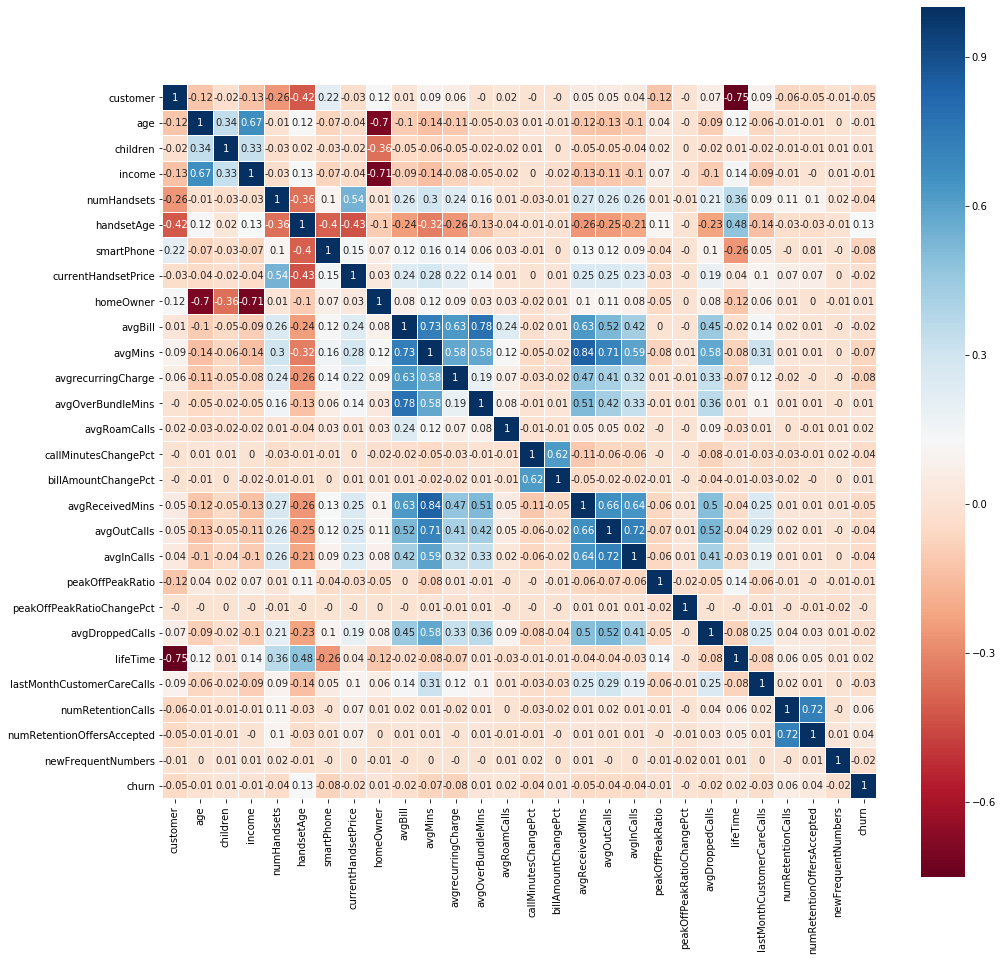

In [89]:
colormap = plt.cm.RdBu
f, axs = plt.subplots(1, 1, figsize=(16, 16))
sns.heatmap(df.corr(method='pearson', min_periods=1).round(decimals=2), linewidths=0.1, vmax=1.0, square=True, 
            cmap=colormap, linecolor='white', annot=True)
#plt.xticks(rotation=30, fontsize=7)
plt.show()

Train test split

In [4]:
ctg_columns = ['occupation', 'regionType', 'marriageStatus']
df_dummy = pd.get_dummies(df, columns=ctg_columns)
df_dummy

,customer,age,children,income,numHandsets,handsetAge,smartPhone,currentHandsetPrice,creditRating,homeOwner,...,occupation_retired,occupation_self-employed,occupation_student,regionType_missing,regionType_rural,regionType_suburban,regionType_town,marriageStatus_no,marriageStatus_unknown,marriageStatus_yes
0,1000004,26.000000,1,6,1,1812,0,0.00,5,1,...,0,0,0,0,0,0,1,0,0,1
1,1000012,36.000000,1,9,4,544,1,79.99,7,0,...,0,0,0,1,0,0,0,0,0,1
2,1000034,74.000000,0,7,2,138,1,29.99,7,0,...,0,0,0,0,0,0,1,0,0,1
3,1000063,30.000000,0,6,3,122,1,9.99,5,0,...,0,0,0,0,0,1,0,1,0,0
4,1000085,32.000000,0,7,8,10,1,129.99,7,0,...,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1099911,52.000000,0,4,1,892,1,0.00,5,1,...,0,0,0,1,0,0,0,0,0,1
9996,1099923,36.000000,0,4,8,337,1,59.99,5,0,...,0,0,0,1,0,0,0,0,0,1
9997,1099939,28.000000,0,2,4,127,1,29.99,6,0,...,0,0,0,1,0,0,0,1,0,0
9998,1099965,42.956078,0,7,5,53,1,59.99,3,0,...,0,0,0,1,0,0,0,0,1,0


In [5]:
df_normed = df_dummy.copy()
df_normed.drop(columns=['customer'], inplace=True)
column_to_nmlz = list(set(df_normed.columns) - set([y_label]))
df_normed[column_to_nmlz] = StandardScaler().fit_transform(df_normed[column_to_nmlz])
train_set_normed, test_set_normed = train_test_split(df_normed, test_size=0.2, random_state=42)
x_train_normed = train_set_normed.drop(columns=[y_label], axis=1)
x_test_normed = test_set_normed.drop(columns=[y_label], axis=1)
y_train = train_set_normed[y_label]
y_test = test_set_normed[y_label]

In [6]:
def dict_product(d):
    keys = d.keys()
    for element in product(*d.values()):
        yield dict(zip(keys, element))

def GridSearchWithVal(model_class, param_grid, metrics='accuracy', cv=5, smote=False):
    combinations = list(dict_product(param_grid))
    max_metrics = 0
    best_comb = None
    X = x_train_normed
    Y = y_train
    _x_test = x_test_normed
    _y_test = y_test
    print("{} combinations in total. Metric: {}".format(len(combinations), metrics))
    for idx, comb in enumerate(combinations):
        model = model_class(**comb)
        model.fit(X, Y)
        y_preds = model.predict(_x_test)
        # print("y_preds:{}".format(y_preds))
        # print("y_test:{}".format(y_test.values))
        error = 0;

        #scores = cross_val_score(model, X, Y, cv=cv, scoring=metrics)
        n_correct = sum(y_preds == _y_test)
        acc = float(n_correct) / len(y_preds)
        metrics_num = acc

        if metrics_num > max_metrics:
            max_metrics = metrics_num
            best_comb = comb
        progress_str = "{} / {}, best comb: {}, best score: {}".format(idx + 1, len(combinations), best_comb, max_metrics)
        sys.stdout.write('\r' + progress_str)

    print("best params:{}".format(best_comb))
    print("max {}: {}".format(metrics, max_metrics))
    return best_comb

Gradient Boosting

In [9]:
gb_param_grid = {"n_estimators" : [10, 30, 50, 70, 100],
                  "loss" : ["deviance", "exponential"],
                  "learning_rate": [0.03, 0.05, 0.08, 0.1],
                  "max_depth": [4, 7, None],
                  "min_samples_leaf": [50, 100, 200, 500],
                  "max_features": [0.3, 0.5, 0.8, None]
                }
gbc_best_param = GridSearchWithVal(GradientBoostingClassifier, gb_param_grid)

1920 combinations in total. Metric: accuracy
1920 / 1920, best comb: {'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.05, 'max_depth': 7, 'min_samples_leaf': 200, 'max_features': None}, best score: 0.628best params:{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.05, 'max_depth': 7, 'min_samples_leaf': 200, 'max_features': None}
max accuracy: 0.628
